In [ ]:
# Load in data.csv
import pandas as pd
df = pd.read_csv('data.csv', sep=';')
display(df.head())

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
financial_df = df[['Debtor', 'Tuition fees up to date', 'Target']]
display(financial_df.head())

,Debtor,Tuition fees up to date,Target
0,0,1,Dropout
1,0,0,Graduate
2,0,0,Dropout
3,0,1,Graduate
4,0,1,Graduate


In [ ]:
admission_df = df[['Previous qualification', 'Previous qualification (grade)', 'Target']]
display(admission_df)
admission_df.info()

,Previous qualification,Previous qualification (grade),Target
0,1,122.0,Dropout
1,1,160.0,Graduate
2,1,122.0,Dropout
3,1,122.0,Graduate
4,1,100.0,Graduate
...,...,...,...
4419,1,125.0,Graduate
4420,1,120.0,Dropout
4421,1,154.0,Dropout
4422,1,180.0,Graduate


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 3 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Previous qualification          4424 non-null   int64  
 1   Previous qualification (grade)  4424 non-null   float64
 2   Target                          4424 non-null   object 
dtypes: float64(1), int64(1), object(1)
memory usage: 103.8+ KB


In [ ]:
X1, y1 = financial_df.drop('Target', axis=1), financial_df['Binary Target']
X2, y2 = admission_df.drop('Target', axis=1), admission_df['Binary Target']

dropout_count = y1.value_counts()[0]
other_count = y1.value_counts()[1]


print('Dropout (0):', dropout_count)
print('Enrolled/Graduate (1):', other_count)


dropout_count2 = y2.value_counts()[0]
other_count2 = y2.value_counts()[1]

print('Dropout (0):', dropout_count2)
print('Enrolled/Graduate (1):', other_count2)

Dropout (0): 1421
Enrolled/Graduate (1): 3003
Dropout (0): 1421
Enrolled/Graduate (1): 3003


/tmp/ipython-input-3113188729.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  financial_df['Binary Target'] = financial_df['Target'].apply(lambda x: 0 if x == 'Dropout' else 1)
/tmp/ipython-input-3113188729.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  admission_df['Binary Target'] = admission_df['Target'].apply(lambda x: 0 if x == 'Dropout' else 1)


In [ ]:
from sklearn.utils import resample

# Separate the classes based on the binary target
df_dropout = financial_df[financial_df['Binary Target'] == 0]
df_other = financial_df[financial_df['Binary Target'] == 1]

# Undersample the majority class to match the minority class size
n_samples = len(df_dropout) # Assuming dropout is the minority class, adjust if needed
df_other_undersampled = resample(df_other, replace=False, n_samples=n_samples, random_state=42)

# Combine the undersampled majority class with the minority class
financial_df_resampled = pd.concat([df_dropout, df_other_undersampled])

# Correctly drop 'Target' and 'Binary Target' from features, keep 'Binary Target' as the target variable
Xfin, yfin = financial_df_resampled.drop(['Target', 'Binary Target'], axis=1), financial_df_resampled['Binary Target']

dropout_count = yfin.value_counts()[0]
other_count = yfin.value_counts()[1]


print('Dropout (0):', dropout_count)
print('Enrolled/Graduate (1):', other_count)

Dropout (0): 1421
Enrolled/Graduate (1): 1421


In [ ]:
from sklearn.utils import resample

# Separate the classes based on the binary target
df_dropout = admission_df[admission_df['Binary Target'] == 0]
df_other = admission_df[admission_df['Binary Target'] == 1]

# Undersample the majority class to match the minority class size
n_samples = len(df_dropout) # Assuming dropout is the minority class, adjust if needed
df_other_undersampled = resample(df_other, replace=False, n_samples=n_samples, random_state=42)

# Combine the undersampled majority class with the minority class
admission_df_resampled = pd.concat([df_dropout, df_other_undersampled])

# Correctly drop 'Target' and 'Binary Target' from features, keep 'Binary Target' as the target variable
Xadmin, yadmin = admission_df_resampled.drop(['Target', 'Binary Target'], axis=1), admission_df_resampled['Binary Target']

dropout_count = yadmin.value_counts()[0]
other_count = yadmin.value_counts()[1]

print('Dropout (0):', dropout_count)
print('Enrolled/Graduate (1):', other_count)

Dropout (0): 1421
Enrolled/Graduate (1): 1421


In [ ]:
# Using logistic regression, test whether the financial_df or admission_df is a better predictor for dropout rate
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_fin_train, X_fin_test, y_fin_train, y_fin_test = train_test_split(Xfin, yfin, test_size=0.2, random_state=42)
X_admin_train, X_admin_test, y_admin_train, y_admin_test = train_test_split(Xadmin, yadmin, test_size=0.2, random_state=42)

# Perform logistic regression on both
fin_model = LogisticRegression()
fin_model.fit(X_fin_train, y_fin_train)
admin_model = LogisticRegression()
admin_model.fit(X_admin_train, y_admin_train)

# Output results of predictions
fin_predictions = fin_model.predict(X_fin_test)
admin_predictions = admin_model.predict(X_admin_test)

# Calculate and print accuracy
fin_accuracy = accuracy_score(y_fin_test, fin_predictions)
admin_accuracy = accuracy_score(y_admin_test, admin_predictions)

print("Financial Model Accuracy:", fin_accuracy)
print("Admission Model Accuracy:", admin_accuracy)

Financial Model Accuracy: 0.6449912126537786
Admission Model Accuracy: 0.5325131810193322


In [ ]:
# Using logistic regression, test whether the financial_df or admission_df is a better predictor for dropout rate
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_fin_train, X_fin_test, y_fin_train, y_fin_test = train_test_split(Xfin, yfin, test_size=0.2, random_state=42)
X_admin_train, X_admin_test, y_admin_train, y_admin_test = train_test_split(Xadmin, yadmin, test_size=0.2, random_state=42)

# Perform logistic regression on both
fin_model = LogisticRegression()
fin_model.fit(X_fin_train, y_fin_train)
admin_model = LogisticRegression()
admin_model.fit(X_admin_train, y_admin_train)

# Output results of predictions
fin_predictions = fin_model.predict(X_fin_test)
admin_predictions = admin_model.predict(X_admin_test)

# Calculate and print accuracy
fin_accuracy = accuracy_score(y_fin_test, fin_predictions)
admin_accuracy = accuracy_score(y_admin_test, admin_predictions)

print("Financial Model Accuracy:", fin_accuracy)
print("Admission Model Accuracy:", admin_accuracy)

Financial Model Accuracy: 0.6449912126537786
Admission Model Accuracy: 0.5325131810193322


In [ ]:
# As a follow up test, I want to see if by removing the financial and admission data and just focusing on student performance, if the model can still accurately predict dropout/graduation
threshhold_df = df[['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Displaced', 'Educational special needs', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target']]

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Separate features (X) and target variable (y)
X = threshhold_df.drop('Target', axis=1)
y = threshhold_df['Target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000) # Increased max_iter
model.fit(X_train, y_train)
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.7265536723163842


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


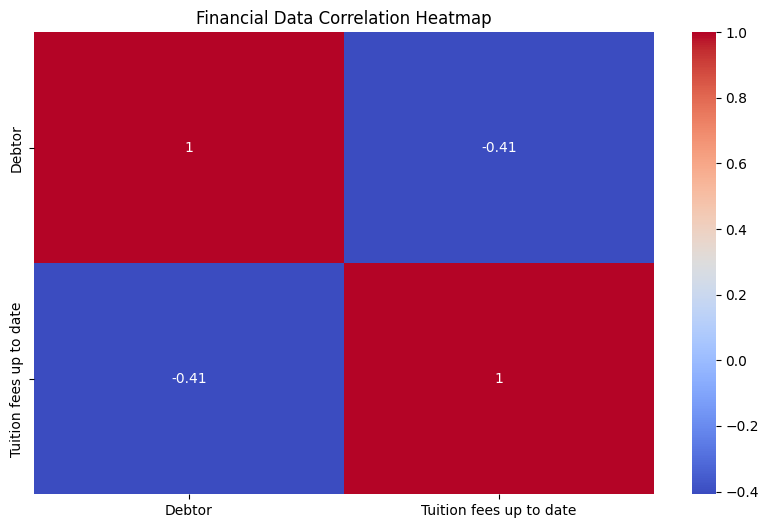

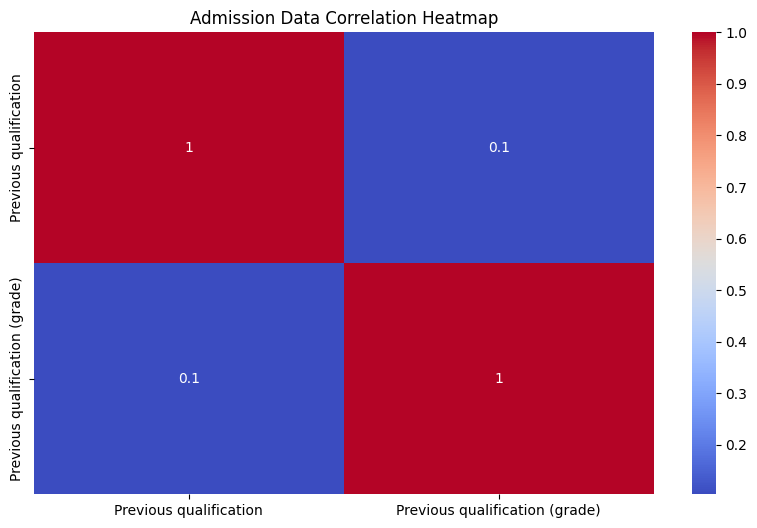

In [ ]:
# Create a heatmap to visualize results
import seaborn as sns
import matplotlib.pyplot as plt

# Create a heatmap to correlate data for financial and admission data
plt.figure(figsize=(10, 6))
sns.heatmap(financial_df.drop('Target', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title('Financial Data Correlation Heatmap')
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(admission_df.drop('Target', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title('Admission Data Correlation Heatmap')
plt.show()

In [ ]:
# Analyze the coefficients of the logistic regression models

print("Financial Model Coefficients:")
for i, col in enumerate(Xfin.columns):
    print(f"{col}: {fin_model.coef_[0][i]}")

print("\nAdmission Model Coefficients:")
for i, col in enumerate(Xadmin.columns):
    print(f"{col}: {admin_model.coef_[0][i]}")

Financial Model Coefficients:
Debtor: -0.588369481329268
Tuition fees up to date: 2.7397726109909275

Admission Model Coefficients:
Previous qualification: -0.0062181803109775825
Previous qualification (grade): 0.012182744658201608


In [ ]:
# Now test whether the financial_df or admission_df is a better predictor for dropout rate using SVM(support vector machine)
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svc_fin = SVC()
svc_fin.fit(X_fin_train, y_fin_train)
svc_admin = SVC()
svc_admin.fit(X_admin_train, y_admin_train)

fin_svc_predictions = svc_fin.predict(X_fin_test)
admin_svc_predictions = svc_admin.predict(X_admin_test)

fin_svc_accuracy = accuracy_score(y_fin_test, fin_svc_predictions)
admin_svc_accuracy = accuracy_score(y_admin_test, admin_svc_predictions)

print("Financial Model Accuracy (SVM):", fin_svc_accuracy)
print("Admission Model Accuracy (SVM):", admin_svc_accuracy)



Financial Model Accuracy (SVM): 0.6449912126537786
Admission Model Accuracy (SVM): 0.5448154657293497


In [ ]:
# Now test whether the financial_df or admission_df is a better predictor for dropout rate using Random Forrest
from sklearn import tree

fin_tree = tree.DecisionTreeClassifier()
fin_tree.fit(X_fin_train, y_fin_train)
admin_tree = tree.DecisionTreeClassifier()
admin_tree.fit(X_admin_train, y_admin_train)



DecisionTreeClassifier()

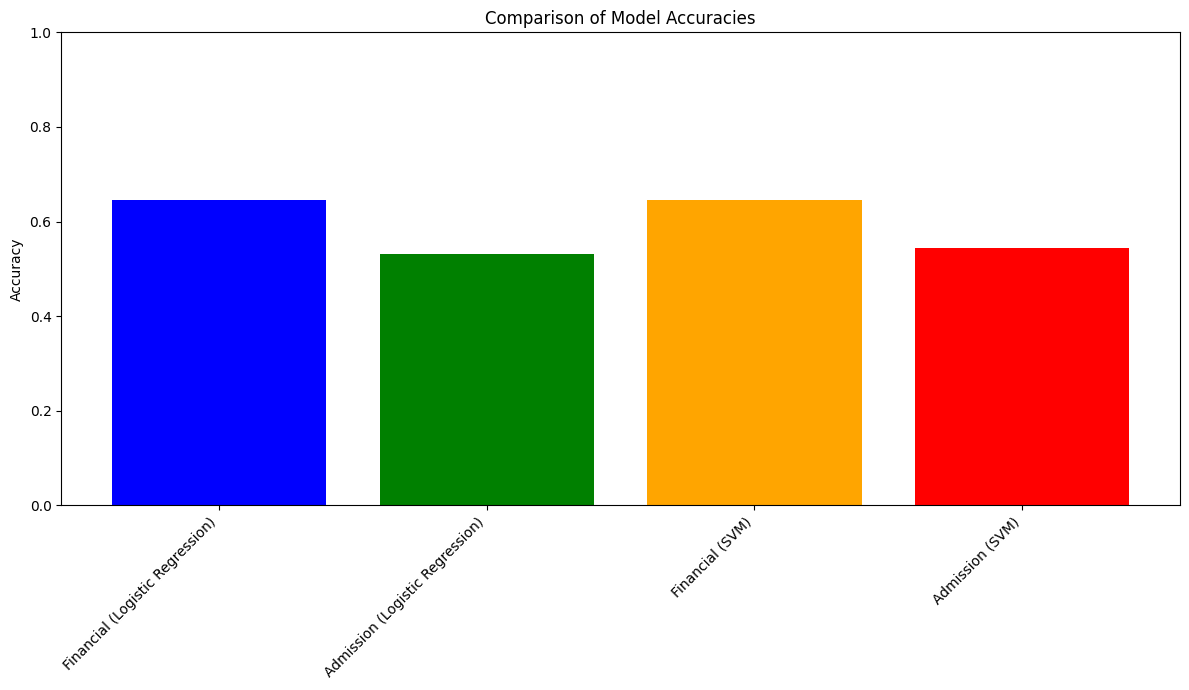

In [ ]:
# Create bar graphs to visualize results
import matplotlib.pyplot as plt

# Data for the bar graph
models = ['Financial (Logistic Regression)', 'Admission (Logistic Regression)', 'Financial (SVM)', 'Admission (SVM)']
accuracies = [fin_accuracy, admin_accuracy, fin_svc_accuracy, admin_svc_accuracy]

plt.figure(figsize=(12, 7))
plt.bar(models, accuracies, color=['blue', 'green', 'orange', 'red'])
plt.ylabel('Accuracy')
plt.title('Comparison of Model Accuracies')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Now create a simple neural network to see if we can achieve higher accuracy with that
import tensorflow as tf
from tensorflow.keras.models import Sequential

# Simple 4 layer NN
fin_model = Sequential()
fin_model.add(tf.keras.layers.Dense(4, activation='tanh', input_shape=(Xfin.shape[1],)))
fin_model.add(tf.keras.layers.Dense(8, activation='tanh'))
fin_model.add(tf.keras.layers.Dense(16, activation='tanh'))
fin_model.add(tf.keras.layers.Dense(32, activation='tanh'))
fin_model.add(tf.keras.layers.Dense(16, activation='tanh'))
fin_model.add(tf.keras.layers.Dense(8, activation='tanh'))
fin_model.add(tf.keras.layers.Dense(4, activation='tanh'))
fin_model.add(tf.keras.layers.Dense(2, activation='softmax'))
fin_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# View results of model accuracy


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Encode the target variable for the admission model
label_encoder_admin = LabelEncoder()
y_admin_train_encoded = label_encoder_admin.fit_transform(y_admin_train)
y_admin_test_encoded = label_encoder_admin.transform(y_admin_test)

# One-hot encode the target variable for the admission model
y_admin_train_categorical = to_categorical(y_admin_train_encoded)
y_admin_test_categorical = to_categorical(y_admin_test_encoded)

# Simple 4 layer NN for the admission data
admin_model = Sequential()
admin_model.add(Dense(4, activation='tanh', input_shape=(Xadmin.shape[1],)))
admin_model.add(Dense(8, activation='tanh'))
admin_model.add(Dense(16, activation='tanh'))
admin_model.add(Dense(32, activation='tanh'))
admin_model.add(Dense(16, activation='tanh'))
admin_model.add(Dense(8, activation='tanh'))
admin_model.add(Dense(4, activation='tanh'))
admin_model.add(Dense(2, activation='softmax'))
admin_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the admission model
admin_model.fit(X_admin_train, y_admin_train_categorical, epochs=10, batch_size=32, verbose=0)

# Evaluate the admission model
loss_admin, accuracy_admin = admin_model.evaluate(X_admin_test, y_admin_test_categorical, verbose=0)
print(f"Admission Model Neural Network Accuracy: {accuracy_admin}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Admission Model Neural Network Accuracy: 0.5043936967849731


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Encode the target variable
label_encoder = LabelEncoder()
y_fin_train_encoded = label_encoder.fit_transform(y_fin_train)
y_fin_test_encoded = label_encoder.transform(y_fin_test)

# One-hot encode the target variable
y_fin_train_categorical = to_categorical(y_fin_train_encoded)
y_fin_test_categorical = to_categorical(y_fin_test_encoded)

# Train the financial model
fin_model.fit(X_fin_train, y_fin_train_categorical, epochs=10, batch_size=32, verbose=0)

# Evaluate the financial model
loss, accuracy = fin_model.evaluate(X_fin_test, y_fin_test_categorical, verbose=0)
print(f"Financial Model Neural Network Accuracy: {accuracy}")

Financial Model Neural Network Accuracy: 0.6502636075019836


# **2nd Hypothesis**

In [2]:
import pandas as pd

# First create a df for field of study dataset
df = pd.read_csv('Most-Recent-Cohorts-Field-of-Study.csv')
FOS_def = df[['CONTROL', 'CIPDESC', 'EARN_MDN_4YR', 'BBRR2_FED_COMP_N']]

FOS_df.head()

# Only keep rows where CIPDESC = Computer Science. , Computer and Information Sciences, General. , Computer Systems Analysis. , Computer/Information Technology Administration and Management. , Computer Engineering.
FOS_df = FOS_df[FOS_df['CIPDESC'].isin(['Computer Science.', 'Computer and Information Sciences, General.', 'Computer Systems Analysis.', 'Computer/Information Technology Administration and Management.', 'Computer Engineering.'])]

FOS_df.head()


,CONTROL,CIPDESC,EARN_MDN_4YR,BBRR2_FED_COMP_N
16,Public,"Computer and Information Sciences, General.",68138,26
17,Public,"Computer and Information Sciences, General.",PS,13
69,Public,"Computer and Information Sciences, General.",86934,29
70,Public,"Computer and Information Sciences, General.",PS,PS
71,Public,"Computer and Information Sciences, General.",PS,PS


In [3]:
FOS_df = FOS_df[FOS_df['CIPDESC'].isin(['Computer Science.', 'Computer and Information Sciences, General.', 'Computer Systems Analysis.', 'Computer/Information Technology Administration and Management.', 'Computer Engineering.'])]

# Drop rows in FOS_df where EARN_MDN_4YR or BBRR2_FED_COMP_N = 'PS'
FOS_df = FOS_df[FOS_df['EARN_MDN_4YR'] != 'PS']
FOS_df = FOS_df[FOS_df['BBRR2_FED_COMP_N'] != 'PS']

# Drop rows where data is NaN
FOS_df = FOS_df.dropna()

print(FOS_df)

                  CONTROL                                            CIPDESC  \
16                 Public        Computer and Information Sciences, General.   
69                 Public        Computer and Information Sciences, General.   
276                Public        Computer and Information Sciences, General.   
464                Public        Computer and Information Sciences, General.   
673                Public        Computer and Information Sciences, General.   
...                   ...                                                ...   
38075  Private, nonprofit        Computer and Information Sciences, General.   
38079  Private, nonprofit  Computer/Information Technology Administration...   
38095  Private, nonprofit                              Computer Engineering.   
38648  Private, nonprofit                                  Computer Science.   
38922              Public        Computer and Information Sciences, General.   

      EARN_MDN_4YR BBRR2_FED_COMP_N  
1

In [ ]:
# For public vs private schools, take a ratio of earnings to debt to figure out which is financially better off
FOS_df['CONTROL'] = FOS_df['CONTROL'].replace({'Private, for-profit': 'Private', 'Private, nonprofit': 'Private'})
private_schools = FOS_df[FOS_df['CONTROL'] == 'Private']
public_schools = FOS_df[FOS_df['CONTROL'] == 'Public']

# PRint private school for test
print(private_schools)

total_public_earnings = 0.0
total_private_earnings = 0.0
total_public_debt = 0.0
total_private_debt = 0.0
public_ratio = 0.0
private_ratio = 0.0

for row in private_schools.itertuples():
  earnings = row.EARN_MDN_4YR
  debt = row.BBRR2_FED_COMP_N
  total_private_earnings += float(earnings)
  total_private_debt += float(debt)

for row in public_schools.itertuples():
  earnings = row.EARN_MDN_4YR
  debt = row.BBRR2_FED_COMP_N
  total_public_earnings += float(earnings)
  total_public_debt += float(debt)

print("Total Public Earnings:", total_public_earnings)
print("Total Public Debt:", total_public_debt)
print("Total Private Earnings:", total_private_earnings)
print("Total Private Debt:", total_private_debt)

public_ratio = total_public_earnings / total_public_debt
private_ratio = total_private_earnings / total_private_debt

print("Public Ratio:", public_ratio)
print("Private Ratio:", private_ratio)


        CONTROL                                            CIPDESC  \
1368    Private  Computer/Information Technology Administration...   
3254    Private  Computer/Information Technology Administration...   
3337    Private                                  Computer Science.   
4687    Private                              Computer Engineering.   
4841    Private        Computer and Information Sciences, General.   
...         ...                                                ...   
227853  Private        Computer and Information Sciences, General.   
227875  Private  Computer/Information Technology Administration...   
228105  Private  Computer/Information Technology Administration...   
228721  Private                                  Computer Science.   
229012  Private  Computer/Information Technology Administration...   

       EARN_MDN_4YR BBRR2_FED_COMP_N  
1368          63039               49  
3254          39513               36  
3337          32558               63  
468